In [1]:
!git clone https://github.com/ayaskovets/pyfnprint.git
%cd pyfnprint

fatal: destination path 'pyfnprint' already exists and is not an empty directory.
/content/pyfnprint


In [2]:
!find . -maxdepth 2 -type f | sort

./example/example.py
./fplib/binarize.py
./fplib/feature.py
./fplib/filter.py
./fplib/image.py
./fplib/__init__.py
./fplib/minutae.py
./fplib/plot.py
./fplib/preprocess.py
./.git/config
./.git/description
./.git/HEAD
./.gitignore
./.git/index
./.git/packed-refs
./LICENSE
./README.md
./references/[1984] A Fast Parallel Algorithm for Thinning Digital Patterns.pdf
./references/[1998] Fingerprint Image Enhancement Algorithm and Performance Evaluation.pdf
./references/[2004] A Memetic Fingerprint Matching Algorithm.pdf
./references/[2005] Use of Ridge Points in Partial Fingerprint.pdf
./references/[2006] An efficient algorithm for fingerprint matching.PDF
./references/[2007] A Memetic Fingerprint Matching Algorithm.pdf
./references/[2007] Use of Ridge Points in Partial Fingerprint.pdf
./references/[2009] Fingerprint Databases and Evaluation.pdf
./references/[2010] A novel similarity measurement for minutiae-based fingerprint verification.pdf
./references/[2010] Fast cartoon + texture image 

In [3]:
!pip install -r requirements.txt

In [4]:
!pip install \
    numpy \
    scipy \
    matplotlib \
    pillow \
    scikit-image \
    opencv-python-headless

In [5]:
import sys
sys.path.append("/content/pyfnprint")

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import fplib.binarize as fpbinarize
import fplib.feature as fpfeature
import fplib.filter as fpfilter
import fplib.image as fpimage
import fplib.minutae as fpminutae
import fplib.preprocess as fppreprocess

print("Import thành công")

Import thành công


Số ảnh: 128
Ảnh đầu tiên: /content/pyfnprint/db/PNG/10_1.png


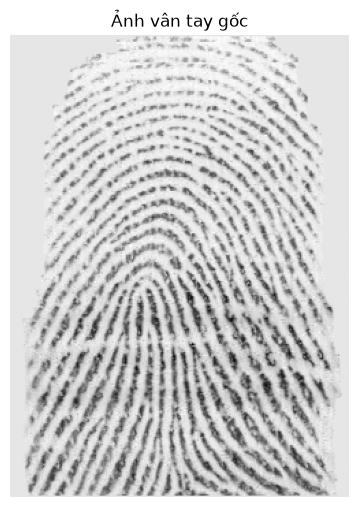

In [7]:
from pathlib import Path
from PIL import Image

sample_files = sorted(Path("/content/pyfnprint/db/PNG").glob("*.png"))

print("Số ảnh:", len(sample_files))
print("Ảnh đầu tiên:", sample_files[0])

img = np.array(Image.open(sample_files[0]).convert("L"))

plt.figure(figsize=(5, 6))
plt.imshow(img, cmap="gray")
plt.title("Ảnh vân tay gốc")
plt.axis("off")
plt.show()

# Bước 1 — Resize
Resize giúp các ảnh có cùng kích thước, từ đó cố định kích thước block và tham số lọc ở các bước sau

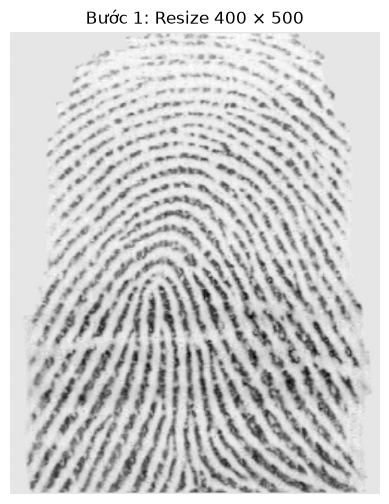

In [8]:
resized = fppreprocess.resize(
    img,
    width=400,
    height=500
)

plt.figure(figsize=(5, 6))
plt.imshow(resized, cmap="gray")
plt.title("Bước 1: Resize 400 × 500")
plt.axis("off")
plt.show()

# Bước 2 — Chuẩn hóa mức xám
Phép chuẩn hóa biến đổi miền cường độ ảnh về khoảng xác định, thường là [0, 255]

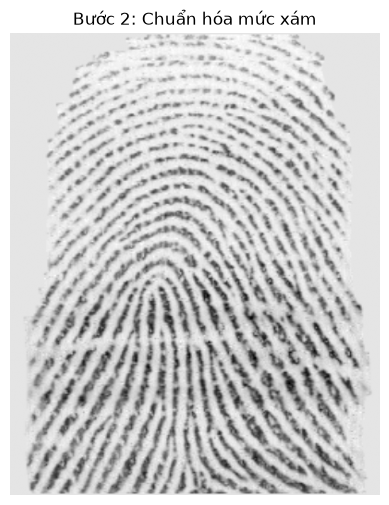

In [9]:
normalized = fppreprocess.normalize(
    resized,
    low=0,
    upp=255
)

plt.figure(figsize=(5, 6))
plt.imshow(normalized, cmap="gray")
plt.title("Bước 2: Chuẩn hóa mức xám")
plt.axis("off")
plt.show()

# Bước 3 — Tạo mask phân đoạn
Mask giúp loại bỏ nền và chỉ giữ vùng có cấu trúc đường vân đáng tin cậy.

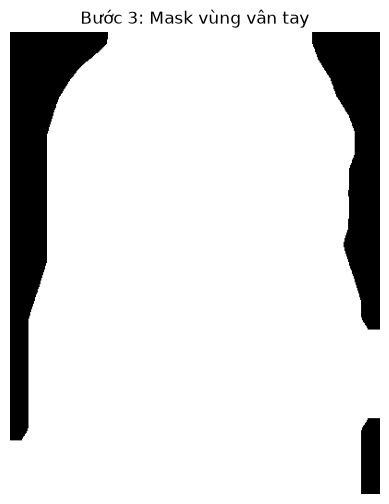

In [10]:
mask = fppreprocess.mask(
    normalized,
    blksize=20
)

plt.figure(figsize=(5, 6))
plt.imshow(mask, cmap="gray")
plt.title("Bước 3: Mask vùng vân tay")
plt.axis("off")
plt.show()

# Bước 4 — Standardization
Standardization đưa dữ liệu về phân bố thuận lợi hơn cho việc tính gradient và hướng đường vân.

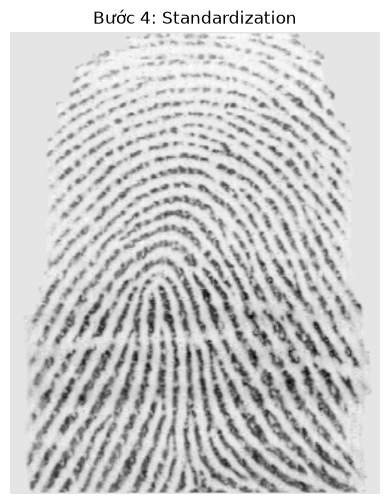

In [11]:
standardized = fppreprocess.standartize(normalized)

plt.figure(figsize=(5, 6))
plt.imshow(standardized, cmap="gray")
plt.title("Bước 4: Standardization")
plt.axis("off")
plt.show()

# Bước 5 — Ước lượng hướng đường vân
Mỗi vùng nhỏ của ảnh được gán một góc đại diện cho hướng đi chủ đạo của ridge.

Orientation shape: (500, 400)
Min: 1.816049927505503e-05
Max: 3.141585757440798


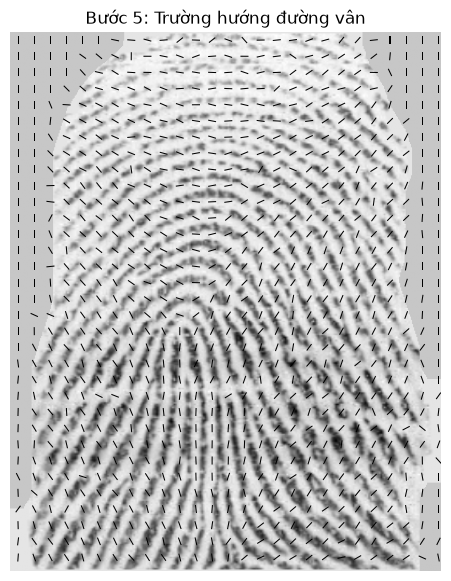

In [12]:
orientation = fppreprocess.orientation(
    standardized,
    grdsigma=3,
    blksigma=3,
    smtsigma=3
)

print("Orientation shape:", orientation.shape)
print("Min:", orientation.min())
print("Max:", orientation.max())

plt.figure(figsize=(6, 7))
plt.imshow(standardized * mask, cmap="gray")

step = 15
y, x = np.mgrid[
    step // 2:orientation.shape[0]:step,
    step // 2:orientation.shape[1]:step
]

theta = orientation[
    step // 2:orientation.shape[0]:step,
    step // 2:orientation.shape[1]:step
]

u = np.cos(theta)
v = np.sin(theta)

plt.quiver(
    x, y, u, v,
    pivot="middle",
    headwidth=0,
    headlength=0,
    headaxislength=0
)

plt.title("Bước 5: Trường hướng đường vân")
plt.axis("off")
plt.show()

# Bước 6 — Ước lượng tần số đường vân
Tần số biểu diễn mật độ ridge trong từng vùng. Hướng và tần số là hai tham số quan trọng để xây dựng bộ lọc Gabor thích nghi.

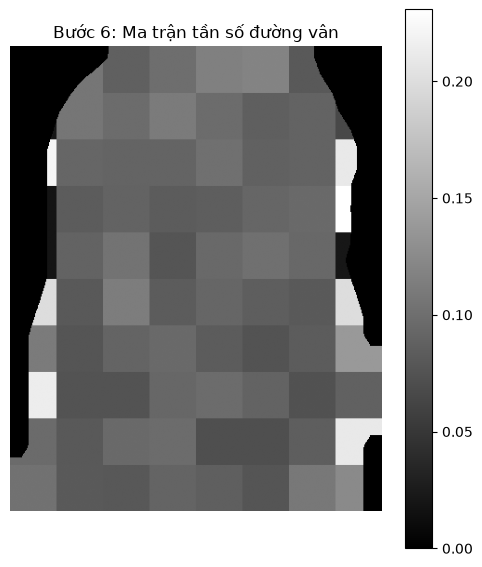

In [13]:
frequency = fppreprocess.frequency(
    standardized,
    orientation,
    blksize=50
)

frequency = frequency * mask

plt.figure(figsize=(6, 7))
plt.imshow(frequency, cmap="gray")
plt.title("Bước 6: Ma trận tần số đường vân")
plt.colorbar()
plt.axis("off")
plt.show()

# Bước 7 — Lọc Gabor
Bộ lọc Gabor tăng cường các ridge có hướng và tần số phù hợp, đồng thời giảm nhiễu không cùng cấu trúc.

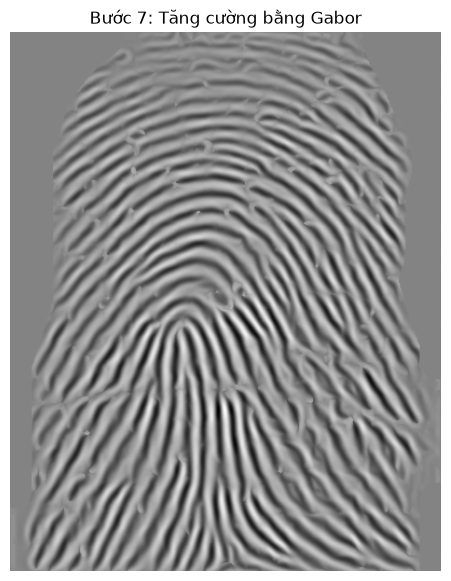

In [14]:
gabor = fpfilter.medgabor(
    standardized,
    orientation,
    frequency
)

plt.figure(figsize=(6, 7))
plt.imshow(gabor, cmap="gray")
plt.title("Bước 7: Tăng cường bằng Gabor")
plt.axis("off")
plt.show()

# Bước 8 — Nhị phân hóa Otsu
Ảnh được chuyển thành hai mức:
- Ridge
- Background

Otsu tự động chọn ngưỡng dựa trên phân bố mức xám.

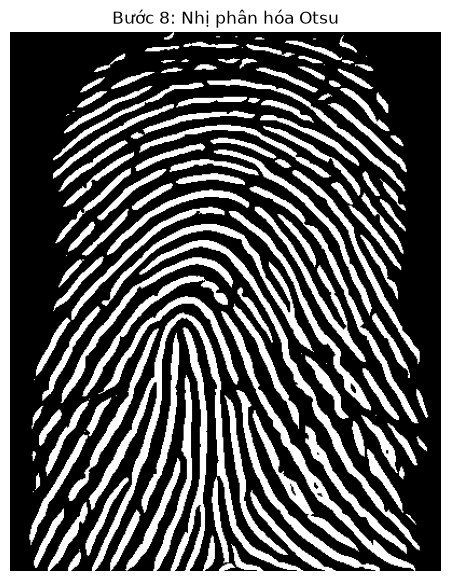

In [15]:
enhanced_uint8 = 255 - fppreprocess.normalize(
    gabor,
    0,
    255,
    np.uint8
)

binary = fpbinarize.binarize(
    enhanced_uint8,
    "otsu"
)

binary = fppreprocess.fillholes(binary)

plt.figure(figsize=(6, 7))
plt.imshow(binary, cmap="gray")
plt.title("Bước 8: Nhị phân hóa Otsu")
plt.axis("off")
plt.show()

# Bước 9 — Skeletonization
Skeletonization làm mảnh ridge về độ rộng gần một pixel, giúp xác định ridge ending và bifurcation.

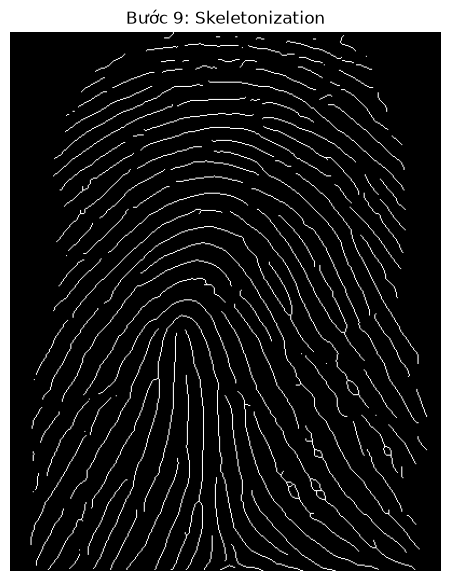

In [16]:
skeleton = fppreprocess.skeleton(binary)

plt.figure(figsize=(6, 7))
plt.imshow(skeleton, cmap="gray")
plt.title("Bước 9: Skeletonization")
plt.axis("off")
plt.show()

# Bước 10 — Pruning
Dùng ba nhóm kernel để pruning và làm sạch skeleton


In [17]:
def prune_skeleton(skeleton):
    pattern_1 = np.array([
        [[1, 0, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 1, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 1], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 1, 1], [0, 0, 0]],
        [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 1, 0], [0, 0, 1]],
        [[0, 0, 0], [0, 1, 0], [0, 1, 0]],
        [[0, 0, 0], [0, 1, 0], [1, 0, 0]],
        [[0, 0, 0], [1, 1, 0], [0, 0, 0]]
    ])

    pattern_2 = np.array([
        [[1, 1, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 1, 1], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 1], [0, 1, 1], [0, 0, 0]],
        [[0, 0, 0], [0, 1, 1], [0, 0, 1]],
        [[0, 0, 0], [0, 1, 0], [0, 1, 1]],
        [[0, 0, 0], [0, 1, 0], [1, 1, 0]],
        [[0, 0, 0], [1, 1, 0], [1, 0, 0]],
        [[1, 0, 0], [0, 1, 0], [1, 0, 0]]
    ])

    pattern_3 = np.array([
        [[1, 1, 1], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 1], [0, 1, 1], [0, 0, 1]],
        [[0, 0, 0], [0, 1, 0], [1, 1, 1]],
        [[1, 0, 0], [1, 1, 0], [1, 0, 0]]
    ])

    result = fppreprocess.prune(skeleton, pattern_1, 8)
    result = fppreprocess.prune(result, pattern_2, 1)
    result = fppreprocess.prune(result, pattern_3, 1)

    return result

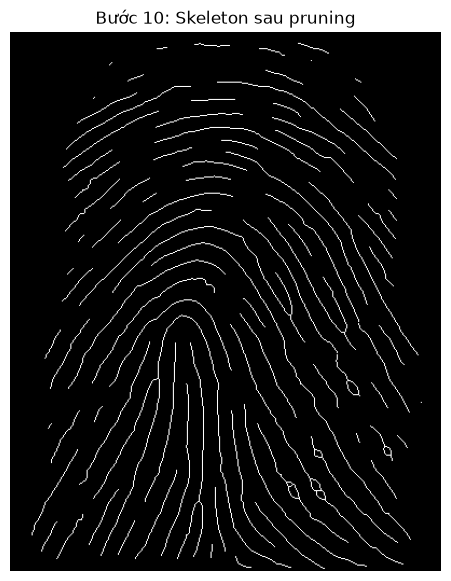

In [18]:
pruned = prune_skeleton(skeleton)

plt.figure(figsize=(6, 7))
plt.imshow(pruned, cmap="gray")
plt.title("Bước 10: Skeleton sau pruning")
plt.axis("off")
plt.show()

# Bước 11 — Trích xuất minutiae
Trích xuất minutiae sau pruning, sau đó thêm core point trước khi tạo vector đặc trưng

In [19]:
minutiae = fpminutae.minutae(
    pruned,
    orientation,
    remove_invalid=1
)

print("Số minutiae:", len(minutiae))
print(minutiae[:5])

Số minutiae: 112
[(62, 208, <MnType.Termination: 3>, np.float64(-2.79))
 (66, 244, <MnType.Termination: 3>, np.float64(9.92))
 (73, 137, <MnType.Termination: 3>, np.float64(-14.57))
 (76, 215, <MnType.Termination: 3>, np.float64(7.05))
 (78, 269, <MnType.Termination: 3>, np.float64(14.47))]


In [20]:
core_point = fpminutae.core(
    orientation,
    mask
)

minutiae_with_core = np.resize(
    minutiae,
    (minutiae.shape[0] + 1,)
)

minutiae_with_core[-1] = core_point

# Bước 12 - Vẽ minutiae trên ảnh
- Do cấu trúc đối tượng minutiae của thư viện cần kiểm tra trực tiếp, cách ổn định nhất ban đầu là dùng hàm có sẵn
- Sau khi kiểm tra được thuộc tính của từng điểm, ta có thể tạo hàm trả về ảnh NumPy để đưa vào demo.

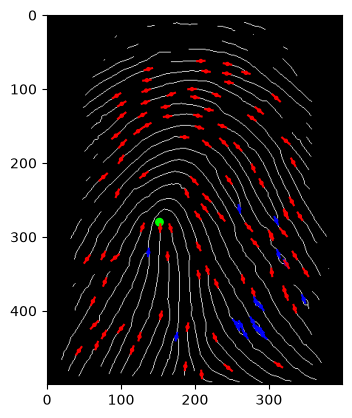

In [21]:
import fplib.plot as fpplot

fpplot.plotminutae(
    pruned,
    minutiae_with_core
)

In [22]:
point = minutiae_with_core[0]

print(type(point))
print(dir(point))
print(point)

<class 'tuple'>
['__add__', '__class__', '__class_getitem__', '__contains__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__rmul__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'count', 'index']
(62, 208, <MnType.Termination: 3>, np.float64(-2.79))


# Bước 13 — Trích xuất vector đặc trưng



In [23]:
feature_radial = fpfeature.extract(
    minutiae_with_core,
    method="radial",
    bucketsize=36
)

feature_circular = fpfeature.extract(
    minutiae_with_core,
    method="circular",
    bucketsize=30
)

print("Radial method:", feature_radial[1])
print("Circular method:", feature_circular[1])

print("Radial vector shape:", np.asarray(feature_radial[0]).shape)
print("Circular vector shape:", np.asarray(feature_circular[0]).shape)

Radial method: radial
Circular method: circular
Radial vector shape: (10,)
Circular vector shape: (9,)


# Xây dựng pineline và hàm matching

In [27]:
from dataclasses import dataclass
from typing import Any

import numpy as np

import fplib.binarize as fpbinarize
import fplib.feature as fpfeature
import fplib.filter as fpfilter
import fplib.minutae as fpminutae
import fplib.preprocess as fppreprocess


@dataclass
class FingerprintResult:
    original: np.ndarray
    resized: np.ndarray
    normalized: np.ndarray
    mask: np.ndarray
    standardized: np.ndarray
    orientation: np.ndarray
    frequency: np.ndarray
    gabor: np.ndarray
    binary: np.ndarray
    skeleton: np.ndarray
    pruned: np.ndarray
    minutiae: Any
    radial_feature: Any
    circular_feature: Any


def ensure_grayscale(image: np.ndarray) -> np.ndarray:
    if image is None:
        raise ValueError("Không đọc được ảnh.")

    if image.ndim == 2:
        return image

    if image.ndim == 3:
        # Dùng công thức luminance, tránh phụ thuộc thứ tự RGB/BGR.
        image = image.astype(np.float32)
        gray = (
            0.299 * image[:, :, 0]
            + 0.587 * image[:, :, 1]
            + 0.114 * image[:, :, 2]
        )
        return np.clip(gray, 0, 255).astype(np.uint8)

    raise ValueError("Ảnh phải có 2 hoặc 3 chiều.")


def prune_skeleton(skeleton: np.ndarray) -> np.ndarray:
    pattern_1 = np.array([
        [[1, 0, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 1, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 1], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 1, 1], [0, 0, 0]],
        [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 0], [0, 1, 0], [0, 0, 1]],
        [[0, 0, 0], [0, 1, 0], [0, 1, 0]],
        [[0, 0, 0], [0, 1, 0], [1, 0, 0]],
        [[0, 0, 0], [1, 1, 0], [0, 0, 0]]
    ])

    pattern_2 = np.array([
        [[1, 1, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 1, 1], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 1], [0, 1, 1], [0, 0, 0]],
        [[0, 0, 0], [0, 1, 1], [0, 0, 1]],
        [[0, 0, 0], [0, 1, 0], [0, 1, 1]],
        [[0, 0, 0], [0, 1, 0], [1, 1, 0]],
        [[0, 0, 0], [1, 1, 0], [1, 0, 0]],
        [[1, 0, 0], [0, 1, 0], [1, 0, 0]]
    ])

    pattern_3 = np.array([
        [[1, 1, 1], [0, 1, 0], [0, 0, 0]],
        [[0, 0, 1], [0, 1, 1], [0, 0, 1]],
        [[0, 0, 0], [0, 1, 0], [1, 1, 1]],
        [[1, 0, 0], [1, 1, 0], [1, 0, 0]]
    ])

    result = fppreprocess.prune(skeleton, pattern_1, 8)
    result = fppreprocess.prune(result, pattern_2, 1)
    result = fppreprocess.prune(result, pattern_3, 1)

    return result


def process_fingerprint(image: np.ndarray) -> FingerprintResult:
    original = ensure_grayscale(image)

    resized = fppreprocess.resize(
        original,
        width=400,
        height=500
    )

    normalized = fppreprocess.normalize(
        resized,
        low=0,
        upp=255
    )

    mask = fppreprocess.mask(
        normalized,
        blksize=20
    )

    standardized = fppreprocess.standartize(normalized)

    orientation = fppreprocess.orientation(
        standardized,
        grdsigma=3,
        blksigma=3,
        smtsigma=3
    )

    frequency = fppreprocess.frequency(
        standardized,
        orientation,
        blksize=50
    )
    frequency = frequency * mask

    gabor = fpfilter.medgabor(
        standardized,
        orientation,
        frequency
    )

    enhanced_uint8 = 255 - fppreprocess.normalize(
        gabor,
        0,
        255,
        np.uint8
    )

    binary = fpbinarize.binarize(
        enhanced_uint8,
        "otsu"
    )
    binary = fppreprocess.fillholes(binary)

    skeleton = fppreprocess.skeleton(binary)
    pruned = prune_skeleton(skeleton)

    minutiae = fpminutae.minutae(
        pruned,
        orientation,
        remove_invalid=1
    )

    minutiae = np.resize(
        minutiae,
        (minutiae.shape[0] + 1,)
    )

    minutiae[-1] = fpminutae.core(
        orientation,
        mask
    )

    radial_feature = fpfeature.extract(
        minutiae,
        method="radial",
        bucketsize=36
    )

    circular_feature = fpfeature.extract(
        minutiae,
        method="circular",
        bucketsize=30
    )

    return FingerprintResult(
        original=original,
        resized=resized,
        normalized=normalized,
        mask=mask,
        standardized=standardized,
        orientation=orientation,
        frequency=frequency,
        gabor=gabor,
        binary=binary,
        skeleton=skeleton,
        pruned=pruned,
        minutiae=minutiae,
        radial_feature=radial_feature,
        circular_feature=circular_feature
    )

In [28]:
@dataclass
class MatchResult:
    radial_distance: float
    circular_distance: float
    total_distance: float
    similarity: float
    threshold: float
    is_match: bool


def match_fingerprints(
    result_a: FingerprintResult,
    result_b: FingerprintResult,
    threshold: float
) -> MatchResult:
    radial_distance = float(
        fpfeature.distance(
            result_a.radial_feature,
            result_b.radial_feature
        )
    )

    circular_distance = float(
        fpfeature.distance(
            result_a.circular_feature,
            result_b.circular_feature
        )
    )

    total_distance = radial_distance + circular_distance

    # Chỉ là phép quy đổi phục vụ trực quan.
    # Không phải xác suất sinh trắc học.
    similarity = 1.0 / (1.0 + max(total_distance, 0.0))

    return MatchResult(
        radial_distance=radial_distance,
        circular_distance=circular_distance,
        total_distance=total_distance,
        similarity=similarity,
        threshold=threshold,
        is_match=total_distance <= threshold
    )

# **Hiệu chỉnh ngưỡng**
- Tạo các cặp ảnh
- Hàm tính khoảng cách
- Thống kê
- Ngưỡng thử nghiệm

In [29]:
same_pairs = [
    ("1_1.png", "1_2.png"),
    ("1_1.png", "1_3.png"),
    ("2_1.png", "2_2.png")
]

different_pairs = [
    ("1_1.png", "2_1.png"),
    ("1_1.png", "3_1.png"),
    ("2_1.png", "4_1.png")
]

In [30]:
from PIL import Image
from pathlib import Path

base_dir = Path("/content/pyfnprint/db/PNG")


def load_gray(filename):
    return np.array(
        Image.open(base_dir / filename).convert("L")
    )


def calculate_distance(file_a, file_b):
    result_a = process_fingerprint(load_gray(file_a))
    result_b = process_fingerprint(load_gray(file_b))

    radial = fpfeature.distance(
        result_a.radial_feature,
        result_b.radial_feature
    )

    circular = fpfeature.distance(
        result_a.circular_feature,
        result_b.circular_feature
    )

    return float(radial + circular)

In [31]:
same_distances = [
    calculate_distance(a, b)
    for a, b in same_pairs
]

different_distances = [
    calculate_distance(a, b)
    for a, b in different_pairs
]

print("Cùng ngón:", same_distances)
print("Khác ngón:", different_distances)

print("Max cùng ngón:", max(same_distances))
print("Min khác ngón:", min(different_distances))

Cùng ngón: [37.44697281520922, 41.08138643037718, 169.97887539170176]
Khác ngón: [165.7087207641706, 124.49444632764826, 178.94370711103767]
Max cùng ngón: 169.97887539170176
Min khác ngón: 124.49444632764826


In [32]:
threshold = (
    max(same_distances)
    + min(different_distances)
) / 2

print("Threshold đề xuất:", threshold)

Threshold đề xuất: 147.236660859675
